In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from rss import evaluate, features, preprocess, train, utils

print('✓ Core libraries imported')

✓ Core libraries imported


In [2]:
CUSTOM_DIR = Path.cwd() # Update with actual path to project directory
# Data directory structure:
# data/
#       sleep-cassette/
#       sleep-telemetry/
DATA_DIR = CUSTOM_DIR / 'data' # Update with actual path to data
SC_DIR = DATA_DIR / 'sleep-cassette'
ST_DIR = DATA_DIR / 'sleep-telemetry'

# Checkpoint directories (modify as needed)
FEATURE_DIR_SC = CUSTOM_DIR / 'checkpoints/features/RF/sc'
FEATURE_DIR_ST = CUSTOM_DIR / 'checkpoints/features/RF/st'
MODEL_DIR = CUSTOM_DIR / 'checkpoints/model/RF'

for path in [FEATURE_DIR_SC, FEATURE_DIR_ST, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print('SC:', SC_DIR)
print('ST:', ST_DIR)
print('Feature checkpoints:', FEATURE_DIR_SC, FEATURE_DIR_ST)
print('Model checkpoint:', MODEL_DIR)

SC: c:\Users\E1024679\Documents\RobustSleepStaging\data\sleep-cassette
ST: c:\Users\E1024679\Documents\RobustSleepStaging\data\sleep-telemetry
Feature checkpoints: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\sc c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\st
Model checkpoint: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\model\RF


In [3]:
def discover_pairs(root_dir):
    """Return sorted (psg, hypnogram) pairs from a Sleep-EDF cohort directory."""
    psgs = sorted(Path(root_dir).glob('*-PSG.edf'))
    pairs = []
    for psg in psgs:
        subject_id = psg.name[:6]
        hyp_files = list(Path(root_dir).glob(f'{subject_id}*-Hypnogram.edf'))
        if hyp_files:
            pairs.append((psg, hyp_files[0]))
    return pairs


sc_pairs = discover_pairs(SC_DIR)
st_pairs = discover_pairs(ST_DIR)
print(f'SC pairs found: {len(sc_pairs)}')
print(f'ST pairs found: {len(st_pairs)}')

example_psg, example_hyp = sc_pairs[0]
raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
annotations = mne.read_annotations(example_hyp)
raw.set_annotations(annotations)

print(f'Example recording: {example_psg.name}')
print(f'Channels in file: {raw.ch_names}')
print(f'Sampling frequency: {raw.info["sfreq"]} Hz')
print(f'Duration: {raw.times[-1] / 3600:.2f} h')
print(f'Annotations: {len(annotations)} segments')

SC pairs found: 153
ST pairs found: 44


C:\Users\E1024679\AppData\Local\Temp\ipykernel_30496\3121516847.py:19: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
C:\Users\E1024679\AppData\Local\Temp\ipykernel_30496\3121516847.py:19: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)
C:\Users\E1024679\AppData\Local\Temp\ipykernel_30496\3121516847.py:19: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(example_psg, preload=True, verbose=False)


Example recording: SC4001E0-PSG.edf
Channels in file: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
Sampling frequency: 100.0 Hz
Duration: 22.08 h
Annotations: 154 segments


C:\Users\E1024679\AppData\Local\Temp\ipykernel_30496\3121516847.py:21: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


[preprocess] loading PSG: SC4011E0-PSG.edf, hypnogram: SC4011EH-Hypnogram.edf


c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:34: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
c:\Users\E1024679\Documents\RobustSleepStaging\rss\preprocess.py:47: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


[preprocess] channels picked: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental'], sampling freq: 100.0 Hz
[preprocess] first sleep onset: 21540.0 seconds
[preprocess] cropped recording from: 19740.0 seconds
[preprocess] kept 30 min of wake before sleep
[preprocess] extracted epochs: 2144 epochs, shape per epoch: (4, 3000) 
[features] computing PSD for 2144 epochs (sfreq=100.0)
[features] PSD computed — elapsed: 2.6s, psd shape: (2144, 3, 1186)
Feature matrix shape: (2144, 3558)
EMG feature matrix shape: (2144, 9)
EMG feature names: ['emg_mean', 'emg_median', 'emg_std', 'emg_min', 'emg_max', 'emg_iqr', 'emg_p90', 'emg_p95', 'emg_rms']


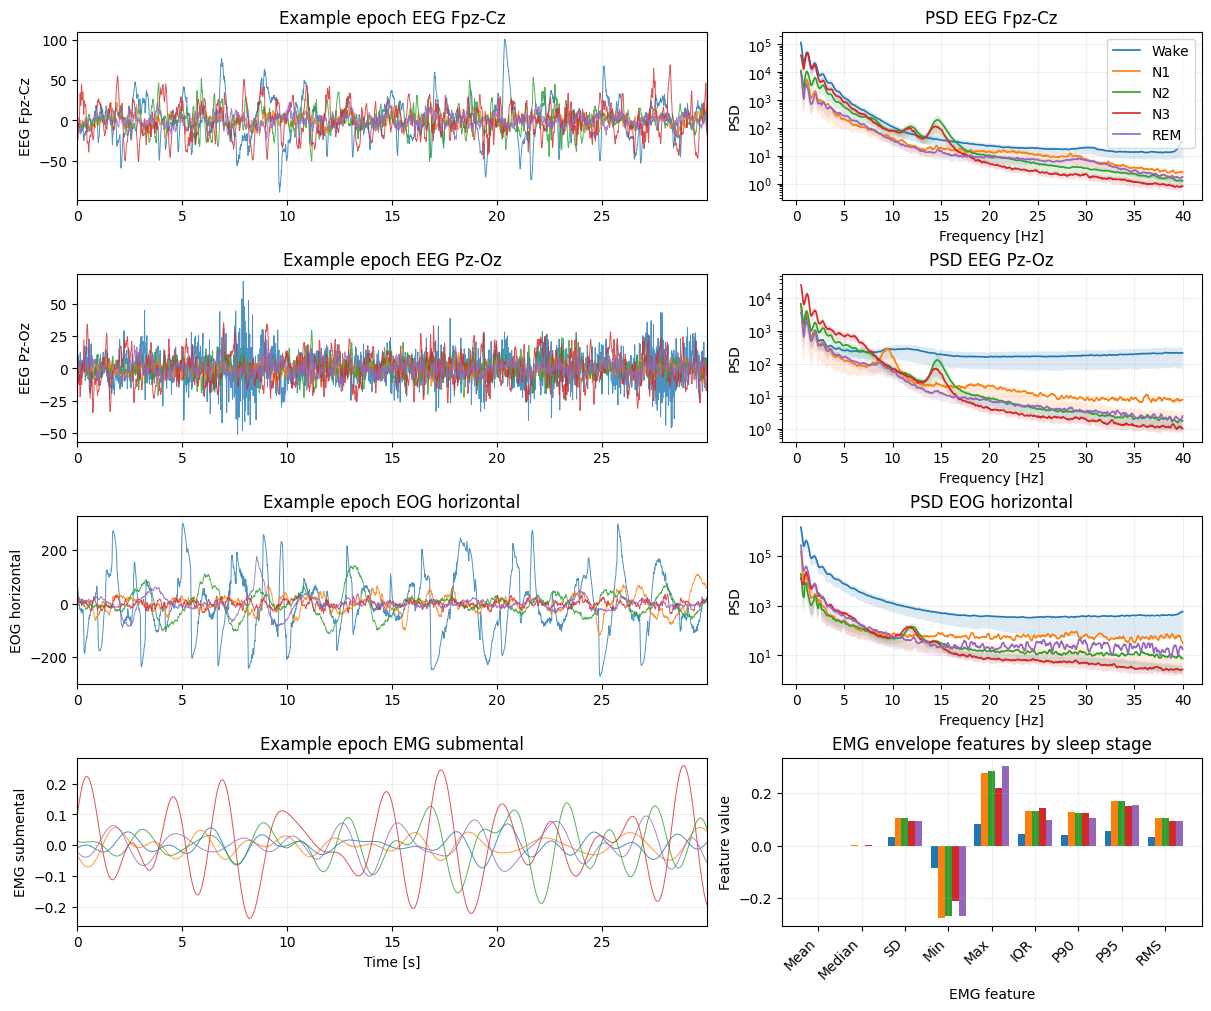

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

EMG_FEATURE_LABELS_SHORT = {
    "emg_mean": "Mean",
    "emg_median": "Median",
    "emg_std": "SD",
    "emg_min": "Min",
    "emg_max": "Max",
    "emg_iqr": "IQR",
    "emg_p90": "P90",
    "emg_p95": "P95",
    "emg_rms": "RMS",
}

X_epochs, y_labels, sfreq = preprocess.load_subject_epochs(sc_pairs[2][0], sc_pairs[2][1], preprocess.COMMON_CHANNELS, verbose=True)
X_features, freqs = features.extract_psd_features(X_epochs[:, :3 , :], sfreq, verbose=True)
X_emg_features, emg_feat_names = features.extract_emg_features(X_epochs[:, 3 , :])
print(f'Feature matrix shape: {X_features.shape}')
print(f'EMG feature matrix shape: {X_emg_features.shape}')
print(f'EMG feature names: {emg_feat_names}')
# Raw snippet
start_sec = 0
end_sec = 30
start_sample = int(start_sec * raw.info["sfreq"])
end_sample = int(end_sec * raw.info["sfreq"])

times = np.arange(start_sample, end_sample) / raw.info["sfreq"]
#data, _ = raw[:len(preprocess.COMMON_CHANNELS), start_sample:end_sample]

# PSD reshape
channel_names = preprocess.COMMON_CHANNELS
n_channels = len(channel_names)
n_freqs = len(freqs)
X_psd = X_features.reshape(len(y_labels), n_channels - 1, n_freqs)

X_epochs = X_epochs.reshape(len(y_labels), n_channels, -1)[:, :, start_sample:end_sample]

fig = plt.figure(figsize=(12, 2.5 * n_channels), constrained_layout=True)
gs = GridSpec(
    n_channels,
    2,
    figure=fig,
    width_ratios=[1.5, 1],
)


stage_labels = np.unique(y_labels)
stage_names = [
    preprocess.STAGE_NAMES.get(int(label), f"label {label}")
    for label in stage_labels
]

for ch_i, channel in enumerate(channel_names):
    # Left: raw trace
    ax_raw = fig.add_subplot(gs[ch_i, 0])

    # Right: PSD or EMG features
    ax_psd = fig.add_subplot(gs[ch_i, 1])

    # -------------------------
    # Left side: example traces
    # -------------------------
    for label in stage_labels:
        mask = y_labels == label
        random_trace = X_epochs[mask, ch_i, :][0]

        stage_name = preprocess.STAGE_NAMES.get(int(label), f"label {label}")

        ax_raw.plot(
            times,
            random_trace,
            lw=0.7,
            alpha=0.8,
            label=stage_name,
        )

    ax_raw.set_title(f"Example epoch {channel}")
    ax_raw.set_ylabel(channel)
    ax_raw.grid(alpha=0.2)
    ax_raw.margins(x=0)

    # -------------------------
    # Right side: PSD or EMG bars
    # -------------------------
    if channel != "EMG submental":
        for label in stage_labels:
            mask = y_labels == label
            stage_name = preprocess.STAGE_NAMES.get(int(label), f"label {label}")

            psd_label = X_psd[mask, ch_i, :]
            mean = psd_label.mean(axis=0)
            lo = np.percentile(psd_label, 25, axis=0)
            hi = np.percentile(psd_label, 75, axis=0)

            ax_psd.plot(freqs, mean, lw=1.2, label=stage_name)
            ax_psd.fill_between(freqs, lo, hi, alpha=0.15)

        ax_psd.set_title(f"PSD {channel}")
        ax_psd.set_yscale("log")
        ax_psd.set_xlabel("Frequency [Hz]")
        ax_psd.set_ylabel("PSD")

    else:
        # Shape: (n_stages, n_emg_features)
        emg_stage_means = []

        for label in stage_labels:
            mask = y_labels == label
            emg_stage_means.append(X_emg_features[mask].mean(axis=0))

        emg_stage_means = np.asarray(emg_stage_means)

        n_features = len(emg_feat_names)
        n_stages = len(stage_labels)

        x = np.arange(n_features)
        bar_width = 0.8 / n_stages

        for stage_i, stage_name in enumerate(stage_names):
            offset = (stage_i - (n_stages - 1) / 2) * bar_width

            ax_psd.bar(
                x + offset,
                emg_stage_means[stage_i],
                width=bar_width,
                label=stage_name,
            )

        ax_psd.set_title("EMG envelope features by sleep stage")
        ax_psd.set_xticks(x)
        ax_psd.set_xticklabels([EMG_FEATURE_LABELS_SHORT.get(name, name) for name in emg_feat_names], rotation=45, ha="right")
        ax_psd.set_ylabel("Feature value")
        ax_psd.set_xlabel("EMG feature")


    ax_psd.grid(alpha=0.2)

    if ch_i == 0:
        ax_psd.legend()

    if ch_i == n_channels - 1:
        ax_raw.set_xlabel("Time [s]")

plt.show()

In [30]:
# Build / load feature arrays from the checkpoint folders
model_path_1 = MODEL_DIR / 'random_forest_sc.pkl'

# Load SC features and labels for training and validation
X_sc, y_sc, sid_sc, feature_names = utils.load_per_record_checkpoints(FEATURE_DIR_SC, load_mode='disk', return_feature_names=True)
print('SC features:', X_sc.shape)
print('Feature names:', feature_names)

if X_sc.size > 0:
    unique_subjects = np.unique(sid_sc)
    print(unique_subjects)
    train_subjects, val_subjects = train_test_split(unique_subjects, test_size=0.2, random_state=42)
    print('Train subjects:', train_subjects)
    print('Validation subjects:', val_subjects)
    train_mask = np.isin(sid_sc, train_subjects)
    val_mask = np.isin(sid_sc, val_subjects)

    X_train_raw = X_sc[train_mask]
    y_train = y_sc[train_mask]
    X_val_raw = X_sc[val_mask]
    y_val = y_sc[val_mask]

    if model_path_1.exists():
        clf_1 = joblib.load(model_path_1)
        print('Loaded existing model checkpoints:')
        print('  no scaling:', model_path_1)
        
    else:
        pass

else:
    print('No SC checkpoints found yet; run the preprocessing cell first.')

[utils] load_mode=disk — scanning checkpoint directory: c:\Users\E1024679\Documents\RobustSleepStaging\checkpoints\features\RF\sc
[utils] found 153 .npz files
[utils] scanned 50/153 files — total_epochs so far: 96419
[utils] scanned 100/153 files — total_epochs so far: 190942
[utils] scanned 150/153 files — total_epochs so far: 291065
SC features: (296936, 246)
Feature names: ['0.75' '1.25' '1.75' '2.25' '2.75' '3.25' '3.75' '4.25' '4.75' '5.25'
 '5.75' '6.25' '6.75' '7.25' '7.75' '8.25' '8.75' '9.25' '9.75' '10.25'
 '10.75' '11.25' '11.75' '12.25' '12.75' '13.25' '13.75' '14.25' '14.75'
 '15.25' '15.75' '16.25' '16.75' '17.25' '17.75' '18.25' '18.75' '19.25'
 '19.75' '20.25' '20.75' '21.25' '21.75' '22.25' '22.75' '23.25' '23.75'
 '24.25' '24.75' '25.25' '25.75' '26.25' '26.75' '27.25' '27.75' '28.25'
 '28.75' '29.25' '29.75' '30.25' '30.75' '31.25' '31.75' '32.25' '32.75'
 '33.25' '33.75' '34.25' '34.75' '35.25' '35.75' '36.25' '36.75' '37.25'
 '37.75' '38.25' '38.75' '39.25' '39.75'

['emg_mean' 'emg_median' 'emg_std' 'emg_min' 'emg_max' 'emg_iqr' 'emg_p90'
 'emg_p95' 'emg_rms']


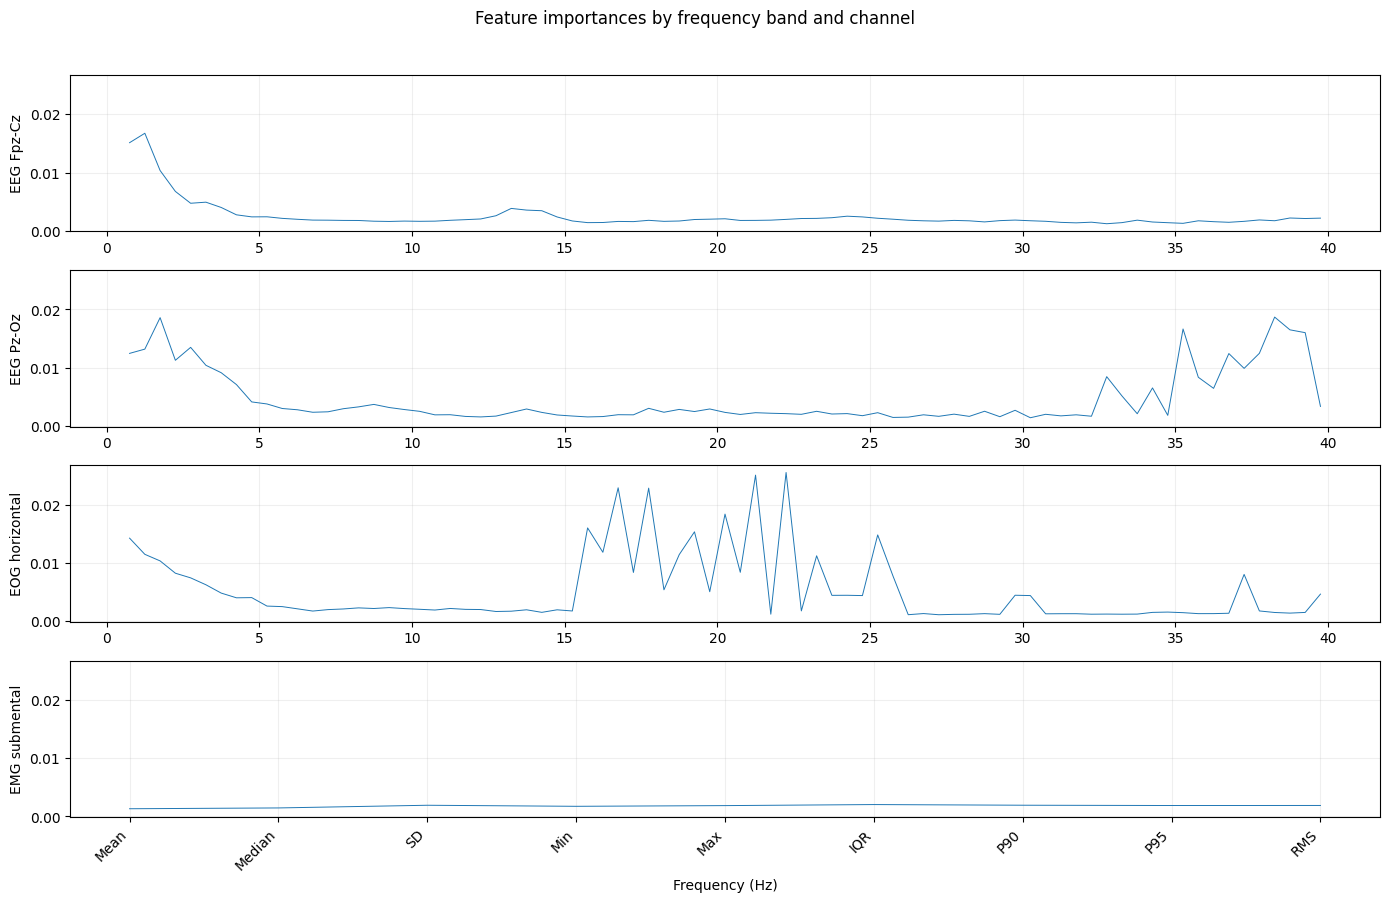

In [31]:
n_freqs = (len(feature_names) - 9) // (len(preprocess.COMMON_CHANNELS) - 1 ) # Assuming 9 EMG features at the end
freqs = feature_names[:n_freqs].astype(float)
emg_feat_names = feature_names[-9:]

print(emg_feat_names)

fig, axes = plt.subplots(len(preprocess.COMMON_CHANNELS), 1, figsize=(14, 2.2 * len(preprocess.COMMON_CHANNELS)), sharey=True)
for i_channel, channel in enumerate(preprocess.COMMON_CHANNELS):
    if i_channel < len(preprocess.COMMON_CHANNELS) - 1:  # Skip EMG channel
        ax = axes[i_channel]
        feature_importances_1 = clf_1.feature_importances_[i_channel * len(freqs):(i_channel + 1) * len(freqs)]
        ax.plot(freqs, feature_importances_1, lw=0.7)
        ax.set_ylabel(channel)
        ax.grid(alpha=0.2)

    elif i_channel == len(preprocess.COMMON_CHANNELS) - 1:
        ax = axes[i_channel]
        emg_feature_importances_1 = clf_1.feature_importances_[i_channel * len(freqs):]
        ax.plot(emg_feat_names, emg_feature_importances_1, lw=0.7)
        ax.set_xticks(emg_feat_names)
        ax.set_xticklabels([EMG_FEATURE_LABELS_SHORT.get(name, name) for name in emg_feat_names], rotation=45, ha="right")
        ax.set_ylabel(channel)
        ax.grid(alpha=0.2)

axes[-1].set_xlabel('Frequency (Hz)')
fig.suptitle('Feature importances by frequency band and channel', y=1.02)
plt.tight_layout()
plt.show()